In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import datetime
import time
from sklearn.linear_model import LogisticRegression
import pyblp
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import KFold
import pickle
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from numpy.random import *
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
import seaborn as sns
import scipy.stats
import warnings
from sklearn.exceptions import ConvergenceWarning
import sys
sys.path.append("src")

from data_generation import *
from neural_networks import *
from estimation import *
from train_varying_products import *

# Ignore ConvergenceWarning from sklearn
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.precision", 4)
pd.options.mode.chained_assignment = None  


In [3]:
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)

In [4]:
item_list = [
    "ACLEGE86",
    "BKCENT73",
    "BKCENT75",
    "BKCENT82",
    "BKCENT90",
    "BW735i85",
    "BW735I86",
    "BW735I87",
    "BW735i88",
    "CDSEVI76",
    "CDSEVI80",
    "CDSEVI81",
    "CDSEVI82",
    "CDSEVI88",
    "CDSEVI90",
    "CVCHEV71",
    "CVCHEV72",
    "CVCHEV76",
    "CVCHEV78",
    "CVCHEV79",
    "CVCHEV86",
    "CVCHEV87",
    "FDESCO81",
    "FDESCO84",
    "FDESCO87",
    "HDACCO76",
    "HDACCO84",
    "HDACCO86",
    "HDACCO90",
    "LCTOWN84",
    "LXLS4090",
    "MZ32386",
    "NIMAXI84",
    "NIMAXI85",
    "NISENT84",
    "NISENT89",'CVCAVA84','LNTOWN90', 'FDTAUR86']

In [5]:
Js = blp_data.groupby(['market_ids']).size().tolist() 
product_id_list = []
for m in range(len(Js)):
    product_id_list.extend(range(Js[m]))  

blp_data['id_in_market'] = product_id_list

In [6]:
blp_data1990 = blp_data.loc[(blp_data.market_ids == 1990) & blp_data.clustering_ids.isin(item_list)]

In [7]:
i_list = blp_data1990.id_in_market.to_list()
j_list = blp_data1990.index.to_list()

In [8]:
blp_data1990

,market_ids,clustering_ids,car_ids,firm_ids,region,shares,prices,hpwt,air,mpd,...,supply_instruments3,supply_instruments4,supply_instruments5,supply_instruments6,supply_instruments7,supply_instruments8,supply_instruments9,supply_instruments10,supply_instruments11,id_in_market
2087,1990,ACLEGE86,5422,3,JP,0.0006,18.9441,0.5097,1,2.3878,...,3.6442,0.5991,126.0,-103.2173,59.0,94.7676,27.7849,76.0,2.3878,1
2095,1990,BW735i88,5434,8,EU,0.0001,37.4904,0.5424,1,1.8851,...,0.9933,0.3455,128.0,-105.6985,57.0,97.6550,27.9555,38.0,1.8851,9
2096,1990,BKCENT90,5438,19,US,0.0012,10.1377,0.3875,1,2.8905,...,24.2643,9.4913,96.0,-79.1094,41.0,73.9565,18.8768,646.0,2.8905,10
2107,1990,CDSEVI90,5452,19,US,0.0004,24.3535,0.5172,1,2.0108,...,24.6272,9.4455,96.0,-79.1094,41.0,73.9565,18.8768,646.0,2.0108,21
2110,1990,CVCAVA84,5456,19,US,0.0031,5.7972,0.3854,0,3.1418,...,24.1809,9.5986,96.0,-79.1094,41.0,73.9565,18.8768,646.0,3.1418,24
2128,1990,FDESCO87,5476,18,US,0.0031,5.6634,0.4014,0,4.0215,...,10.7442,4.3342,115.0,-92.1980,52.0,87.1464,24.1956,285.0,4.0215,42
2133,1990,FDTAUR86,5483,18,US,0.0033,9.6710,0.3045,0,2.2621,...,11.3195,4.1562,115.0,-92.1980,52.0,87.1464,24.1956,285.0,2.2621,47
2139,1990,HDACCO90,5489,3,JP,0.0044,9.2923,0.4565,0,3.0162,...,3.4106,0.6280,126.0,-103.2173,59.0,94.7676,27.7849,76.0,3.0162,53
2150,1990,LXLS4090,5502,1,JP,0.0004,27.5440,0.6651,1,2.2621,...,6.7261,1.3040,122.0,-100.8703,56.0,91.7399,26.9920,152.0,2.2621,64
2153,1990,LNTOWN90,5505,18,US,0.0016,21.4124,0.3727,1,2.1364,...,11.3767,3.9021,115.0,-92.1980,52.0,87.1464,24.1956,285.0,2.1364,67


### Figure 4(a) - No IV - our model

In [11]:
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
blp_data = blp_data[['market_ids', 'clustering_ids', 'car_ids', 'firm_ids', 'region',
       'shares', 'prices', 'hpwt', 'air', 'mpd', 'space']] #

blp_data_new = blp_data.copy()
blp_data_new['market_code'] = pd.Categorical(blp_data_new['market_ids']).codes
blp_market_id = blp_data_new['market_code'].to_numpy()

## Get the J_list
Js = blp_data_new.groupby(['market_ids']).size().tolist() 

J_list = [0]
for m in range(len(Js)):
    J_list.append(J_list[m] + Js[m])

## sort by market code
blp_X = blp_data_new[['hpwt', 'air', 'mpd', 'space']]

blp_X['price'] = blp_data_new['prices']
blp_X.columns = range(len(blp_X.columns))
blp_X = blp_X.rename(columns={blp_X.columns[-1]: 'price'})

blp_Y = blp_data_new['shares'].to_numpy()

blp_data_deep = {'X': blp_X, 
             'Y': blp_Y ,  
             'M': len(blp_data['market_ids'].unique()), 
             "K": blp_X.shape[1]-1, 
            'J': blp_data.groupby(['market_ids']).size().max(), # max_J
            'J_list': J_list,
             'market_id':blp_market_id,
            'params' : 1} # the params does not mean anything here

In [12]:
m0_deep, l0_blp = train_deep_varying(blp_data_deep)

In [ ]:
m0_pred = pred_deep_varying(blp_data_deep, m0_deep)

In [ ]:
Js = blp_data.groupby(['market_ids']).size().tolist() 
product_id_list = []
for m in range(len(Js)):
    product_id_list.extend(range(Js[m]))  

blp_data['id_in_market'] = product_id_list

blp_data1990 = blp_data.loc[(blp_data.market_ids == 1990) & blp_data.clustering_ids.isin(item_list)]

i_list = blp_data1990.id_in_market.to_list()
j_list = blp_data1990.index.to_list()

In [ ]:
### step 5: evaluation on predicted elasticity
data = blp_data_deep
model = m0_deep
delta = 1

J = data['J']
K = data['K']
M = data['M']

large_record4  = pd.DataFrame()

for i in range(J):
    prod_id = i
    
    X = data['X'].copy()
    record = pd.DataFrame({'old_price' : X['price'].copy()})
    record['i'] = prod_id
    record['j'] = record.index 
    
    y_pred_old = pred_deep_varying(data, model)

    ## update price of id in all markets
    record['market_id'] = data['market_id']
    record['type'] = 'cross'
    record['price_i'] = 0
    
    for m in range(M):
        if prod_id < J_list[m+1] - J_list[m]:
            new_id = prod_id + J_list[m]
            price_i = X['price'].iloc[new_id]
            record['price_i'].iloc[J_list[m]:J_list[m+1],] = price_i 
            X['price'].iloc[new_id] =  delta + price_i
            record['type'].iloc[new_id] = "self"
            #print(prod_id, m, new_id, price_i)
    record['new_price'] = X['price'].copy()
    
    ## predict based on new price
    datax = {'X': X, 'Y': data['Y'], 'J': J, "K": K, "M": M, 'J_list': data['J_list'],"params": data['params'], 'market_id': data['market_id']}
    y_new = pred_deep_varying(datax, model)
    
    record['deep_old_share'] = y_pred_old
    record['deep_new_share'] = y_new

    record['deep_elasticity'] = (record['deep_new_share'] - record['deep_old_share']) / (delta / record['price_i'] ) #* record['deep_old_share'] because we use the log
    
    large_record4 = pd.concat([large_record4, record]).reset_index(drop=True)

In [ ]:
large_record4_valid = large_record4.loc[large_record4.price_i !=0]
large_record4_valid.to_csv('noIV_rslt.csv')

In [15]:
large_record4_valid = pd.read_csv('noIV_rslt.csv')

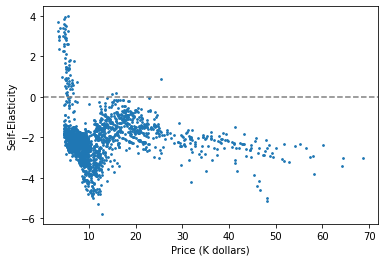

In [17]:
plt.scatter(large_record4_valid.loc[large_record4_valid.type == 'self']['price_i'],large_record4_valid.loc[large_record4_valid.type == 'self']['deep_elasticity'], s=3)
plt.xlabel('Price (K dollars)')
plt.ylabel('Self-Elasticity')
#plt.title('')
plt.axhline(y=0, color='gray', linestyle='--')

plt.savefig('elas_noIV.png', dpi=300)

plt.show()

### Figure 4 (b) + Table 7 (a)

In [1098]:
new_iv = pd.read_csv("BLP_new_IV.csv")
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)

In [ ]:
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
blp_ivs = blp_data[['prices', 'supply_instruments0',   'supply_instruments1', 'supply_instruments2', 'supply_instruments3',
       'supply_instruments4', 'supply_instruments5', 'supply_instruments6',
       'supply_instruments7', 'supply_instruments8', 'supply_instruments9',
       'supply_instruments10', 'supply_instruments11',
                 ]]#

blp_ivs[['lag_ln_erate', 'ln_wage']] = new_iv[['lag_ln_erate', 'ln_wage']] 
# use the mliv
regr = LassoCV(cv = 3, random_state = 234) # XGBRegressor(cv = 3) #LassoCV(cv = 2)# or 
blp_ivs['liv'] = cross_val_predict(regr , blp_ivs[[col for col in blp_ivs.columns if col != 'prices']], blp_ivs['prices'], cv = 3)

# 
y = blp_ivs[ 'prices']
X = blp_ivs[['liv']] #
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
iv_model = sm.OLS(y, X).fit()
phat =  iv_model.fittedvalues
residuals = iv_model.resid

blp_data['res'] = residuals 

In [ ]:
X = blp_ivs[[col for col in blp_ivs.columns if col != 'prices']]
y = blp_ivs['prices']

# Fit the model
regr = LassoCV(cv = 3, random_state = 234)
regr.fit(X, y)

In [1101]:
blp_data = blp_data[['market_ids', 'clustering_ids', 'car_ids', 'firm_ids', 'region',
       'shares', 'prices', 'hpwt', 'air', 'mpd', 'space','res']]

blp_data_new = blp_data.copy()
blp_data_new['market_code'] = pd.Categorical(blp_data_new['market_ids']).codes
blp_market_id = blp_data_new['market_code'].to_numpy()

## Get the J_list
Js = blp_data_new.groupby(['market_ids']).size().tolist() 

J_list = [0]
for m in range(len(Js)):
    J_list.append(J_list[m] + Js[m])

## sort by market code
blp_X = blp_data_new[['hpwt', 'air', 'mpd', 'space','res']]

blp_X['price'] = blp_data_new['prices']
blp_X.columns = range(len(blp_X.columns))
blp_X = blp_X.rename(columns={blp_X.columns[-1]: 'price'})

blp_Y = blp_data_new['shares'].to_numpy()

blp_data_deep = {'X': blp_X, 
             'Y': blp_Y ,  
             'M': len(blp_data['market_ids'].unique()), 
             "K": blp_X.shape[1]-1, 
            'J': blp_data.groupby(['market_ids']).size().max(), # max_J
            'J_list': J_list,
             'market_id':blp_market_id,
            'params' : 1} # the params does not mean anything here

In [1102]:
m4_deep, l4_blp = train_deep_varying(blp_data_deep)

In [1103]:
m4_pred = pred_deep_varying(blp_data_deep, m4_deep)

In [1170]:
### step 5: evaluation on predicted elasticity
data = blp_data_deep
model = m4_deep
delta = 1

J = data['J']
K = data['K']
M = data['M']

large_record4  = pd.DataFrame()

for i in range(J): #i_list:#
    prod_id = i
    
    X = data['X'].copy()
    record = pd.DataFrame({'old_price' : X['price'].copy()})
    record['i'] = prod_id
    record['j'] = record.index 
    
    y_pred_old = pred_deep_varying(data, model)

    ## update price of id in all markets
    record['market_id'] = data['market_id']
    record['type'] = 'cross'
    record['price_i'] = 0
    
    for m in range(M):
        if prod_id < J_list[m+1] - J_list[m]:
            new_id = prod_id + J_list[m]
            price_i = X['price'].iloc[new_id]
            record['price_i'].iloc[J_list[m]:J_list[m+1],] = price_i 
            X['price'].iloc[new_id] =  delta + price_i
            record['type'].iloc[new_id] = "self"
            #print(prod_id, m, new_id, price_i)
    record['new_price'] = X['price'].copy()
    
    ## predict based on new price
    datax = {'X': X, 'Y': data['Y'], 'J': J, "K": K, "M": M, 'J_list': data['J_list'],"params": data['params'], 'market_id': data['market_id']}
    y_new = pred_deep_varying(datax, model)
    
    record['deep_old_share'] = y_pred_old
    record['deep_new_share'] = y_new

    record['deep_elasticity'] = (record['deep_new_share'] - record['deep_old_share']) / (delta / record['price_i'] ) #* record['deep_old_share'] because we use the log
    
    large_record4 = pd.concat([large_record4, record]).reset_index(drop=True)

In [1171]:
large_record4_valid = large_record4.loc[large_record4.price_i != 0]

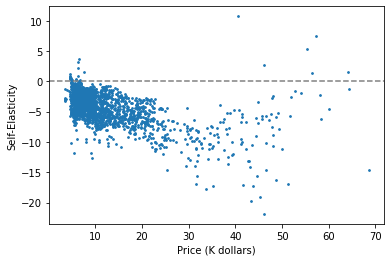

In [1173]:
plt.scatter(large_record4_valid.loc[large_record4.type == 'self']['price_i'],large_record4_valid.loc[large_record4.type == 'self']['deep_elasticity'], s=3)
plt.xlabel('Price (K dollars)')
plt.ylabel('Self-Elasticity')
#plt.title('')
plt.axhline(y=0, color='gray', linestyle='--')

plt.savefig('elas_IV.png', dpi=300)

plt.show()

In [ ]:
large_record4['share_change'] = large_record4['deep_elasticity'] * 1 / large_record4['price_i']

our_rslt2 = pd.DataFrame(large_record4.loc[(large_record4.market_id == 19) &
                        (large_record4['i'].isin(i_list)) & 
                         (large_record4['j'].isin(j_list))]['deep_elasticity'].to_numpy().reshape((13,13)))

our_rslt2.index = car_names
our_rslt2.columns = car_names

our_rslt2

,Acura Legend,BMW 735i,Buick Century,Cadillac Seville,Chevy Cavalier,Ford Escort,Ford Taurus,Honda Accord,Lexus LS400,Lincoln Town Car,Mazda 323,Nissan Maxima,Nissan Sentra
Acura Legend,-5.6060,0.1993,0.2198,0.2221,0.0632,0.2317,0.2199,0.2337,0.2144,0.2187,0.2595,0.2354,0.2595
BMW 735i,0.4095,-6.1528,0.3653,0.4093,0.0352,0.3525,0.3655,0.3807,0.4120,0.4084,0.3547,0.4161,0.3547
Buick Century,0.1234,0.1020,-6.1023,0.1213,0.0376,0.1294,0.1215,0.1205,0.1175,0.1191,0.1400,0.1299,0.1400
Cadillac Seville,0.2895,0.2179,0.2631,-7.2896,0.0647,0.2692,0.2631,0.2566,0.2810,0.2818,0.2892,0.2849,0.2892
Chevy Cavalier,0.0142,-0.0013,0.0202,0.0167,-1.3447,0.0171,0.0202,0.0353,0.0126,0.0167,0.0354,0.0291,0.0355
Ford Escort,0.0410,0.0245,0.0353,0.0413,-0.0148,-1.8519,0.0353,0.0520,0.0392,0.0413,0.0494,0.0513,0.0494
Ford Taurus,0.1166,0.0914,0.1188,0.1160,0.0183,0.1199,-6.1473,0.1258,0.1066,0.1157,0.1451,0.1290,0.1451
Honda Accord,0.0975,0.0647,0.0968,0.1006,-0.0003,0.0945,0.0969,-5.7438,0.0914,0.1006,0.1166,0.1140,0.1165
Lexus LS400,0.3357,0.2606,0.3136,0.3325,0.0822,0.3235,0.3137,0.3126,-6.8791,0.3271,0.3495,0.3348,0.3494
Lincoln Town Car,0.2681,0.2310,0.2548,0.2656,0.0713,0.2663,0.2548,0.2648,0.2586,-5.3996,0.3009,0.2719,0.3009


In [1234]:
large_record4_valid.to_csv('IV_rslt.csv',index=False)

### Table 7 (b)

In [40]:
product_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
product_data.head()

,market_ids,clustering_ids,car_ids,firm_ids,region,shares,prices,hpwt,air,mpd,...,supply_instruments2,supply_instruments3,supply_instruments4,supply_instruments5,supply_instruments6,supply_instruments7,supply_instruments8,supply_instruments9,supply_instruments10,supply_instruments11
0,1971,AMGREM71,129,15,US,0.0011,4.9358,0.5290,0,1.8881,...,0.0,1.7059,1.5957,87.0,-61.96,0.0,46.0604,29.787,0.0,1.8881
1,1971,AMHORN71,130,15,US,0.0007,5.5160,0.4943,0,1.9360,...,0.0,1.6809,1.4903,87.0,-61.96,0.0,46.0604,29.787,0.0,1.9360
2,1971,AMJAVL71,132,15,US,0.0003,7.1086,0.4676,0,1.7168,...,0.0,1.8011,1.3577,87.0,-61.96,0.0,46.0604,29.787,0.0,1.7168
3,1971,AMMATA71,134,15,US,0.0005,6.8395,0.4265,0,1.6879,...,0.0,1.8181,1.2613,87.0,-61.96,0.0,46.0604,29.787,0.0,1.6879
4,1971,AMAMBS71,136,15,US,0.0004,8.9284,0.4525,0,1.5043,...,0.0,1.9332,1.2374,87.0,-61.96,0.0,46.0604,29.787,0.0,1.5043


In [41]:
product_data = product_data

In [42]:
product_formulations = (
   pyblp.Formulation('0 + prices + hpwt + air + mpd + space'), #1 + hpwt + air + mpd + space
   pyblp.Formulation('1 + prices + hpwt + air + mpd + space '), #
   #pyblp.Formulation('1 + log(hpwt) + air + log(mpg) + log(space) + trend')
)
product_formulations

(prices + hpwt + air + mpd + space, 1 + prices + hpwt + air + mpd + space)

In [43]:
mc_integration = pyblp.Integration('monte_carlo', size=50, specification_options={'seed': 0})
bfgs = pyblp.Optimization('bfgs', {'gtol': 1e-4})
mc_problem = pyblp.Problem(product_formulations, product_data, integration=mc_integration)

Initializing the problem ...
Initialized the problem after 00:00:00.

Dimensions:
 T    N     F    I     K1    K2    MD 
---  ----  ---  ----  ----  ----  ----
20   2217  26   1000   5     6     12 

Formulations:
       Column Indices:           0       1      2     3     4      5  
-----------------------------  ------  ------  ----  ---  -----  -----
 X1: Linear Characteristics    prices   hpwt   air   mpd  space       
X2: Nonlinear Characteristics    1     prices  hpwt  air   mpd   space


In [44]:
initial_sigma = np.diag([3.612, -0.1, 4.628, 1.818, 1.050, 2.056]) 
results = mc_problem.solve(
    initial_sigma,
    optimization=bfgs
)


In [46]:
m2_blp = results

In [47]:
blp_elas = m2_blp.compute_elasticities()

Computing elasticities with respect to prices ...
Finished after 00:00:00.



In [56]:
blp_elas_df = pd.DataFrame(blp_elas, columns=range(blp_elas.shape[1]))

# Add a column for the row indices
blp_elas_df['row_index'] = range(blp_elas.shape[0])

# Reshape the dataframe so that the column indices are in a column called 'column_index'
blp_elas_df = blp_elas_df.melt(id_vars='row_index', var_name='column_index', value_name='value')

blp_elas_df.columns = ['i','j','blp_elasticity']
blp_elas_df = blp_elas_df.loc[blp_elas_df['blp_elasticity'].isna() == False]

blp_elas_df = pd.merge(blp_elas_df, blp_data[['id_in_market', 'market_ids']],
                       how ='left', left_on =['i'], right_on = blp_data.index)


In [58]:
blp_elas_df.to_csv('blp_elas_df.csv',index = False)

In [57]:
blp_elas_df_self = blp_elas_df.loc[blp_elas_df['id_in_market'] == blp_elas_df['j']].copy()
blp_elas_df_cross = blp_elas_df.loc[blp_elas_df['id_in_market'] != blp_elas_df['j']].copy()

In [1228]:
car_names = ['Acura Legend', 'BMW 735i', 'Buick Century', 'Cadillac Seville', 'Chevy Cavalier', 'Ford Escort', 'Ford Taurus',
            'Honda Accord', 'Lexus LS400', 'Lincoln Town Car', 'Mazda 323', 'Nissan Maxima','Nissan Sentra']

In [1229]:
blp_rslt = pd.DataFrame(blp_elas[np.ix_(j_list, i_list)])

blp_rslt.index = car_names
blp_rslt.columns = car_names

blp_rslt

,Acura Legend,BMW 735i,Buick Century,Cadillac Seville,Chevy Cavalier,Ford Escort,Ford Taurus,Honda Accord,Lexus LS400,Lincoln Town Car,Mazda 323,Nissan Maxima,Nissan Sentra
Acura Legend,-5.4677,0.0489,0.0205,0.1029,0.0221,0.0220,0.0143,0.1477,0.1503,0.0273,0.0013,0.1359,0.0039
BMW 735i,0.1267,-9.8502,0.0156,0.1058,0.0122,0.0121,0.0057,0.1313,0.1546,0.0278,0.0006,0.1375,0.0022
Buick Century,0.0184,0.0054,-5.1978,0.0124,0.1153,0.1043,0.1475,0.1982,0.0165,0.0800,0.0076,0.0379,0.0174
Cadillac Seville,0.1293,0.0513,0.0175,-6.6819,0.0151,0.0150,0.0099,0.1393,0.1576,0.0271,0.0008,0.1406,0.0027
Chevy Cavalier,0.0131,0.0028,0.0766,0.0071,-3.1163,0.1421,0.0849,0.2608,0.0086,0.0404,0.0100,0.0395,0.0241
Ford Escort,0.0137,0.0029,0.0726,0.0074,0.1487,-3.0590,0.0603,0.2781,0.0090,0.0263,0.0106,0.0419,0.0258
Ford Taurus,0.0048,0.0007,0.0554,0.0027,0.0479,0.0326,-4.0258,0.0727,0.0017,0.1779,0.0026,0.0122,0.0057
Honda Accord,0.0387,0.0133,0.0582,0.0291,0.1151,0.1173,0.0568,-4.3399,0.0409,0.0297,0.0081,0.0618,0.0200
Lexus LS400,0.1350,0.0536,0.0166,0.1126,0.0130,0.0130,0.0045,0.1400,-7.4316,0.0243,0.0006,0.1464,0.0024
Lincoln Town Car,0.0087,0.0034,0.0286,0.0069,0.0217,0.0135,0.1693,0.0362,0.0086,-5.6139,0.0011,0.0123,0.0024


### Figure 5

In [36]:
large_record4_valid = pd.read_csv("IV_rslt.csv")

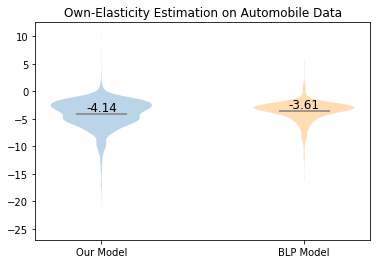

In [73]:
data = [large_record4_valid.loc[large_record4_valid.type == 'self','deep_elasticity'].to_numpy(), blp_elas_df_self['blp_elasticity'].to_numpy()]
fig, ax = plt.subplots()

# Create the violinplot
violins = ax.violinplot(data, showextrema = False, showmeans = True)

# Set colors for each violin plot
colors = ['#1f77b4', '#FF8C00']
for i, body in enumerate(violins['bodies']):
    body.set_facecolor(colors[i])

violins['cmeans'].set_color('grey')

# Set the labels for the x-axis
ax.set_xticks([1, 2])
ax.set_xticklabels(['Our Model', 'BLP Model'])

plt.title("Own-Elasticity Estimation on Automobile Data")

# Calculate mean values
mean_values = [np.mean(dataset) for dataset in data]

# Add the mean values as text labels on the violin plot
for i, mean in enumerate(mean_values):
    ax.text(i+1, mean, f'{mean:.2f}', ha='center', va='bottom', color='black', fontsize=12)

# Show the plot
plt.savefig('self_comparison_blp.png', dpi=300)

plt.show()


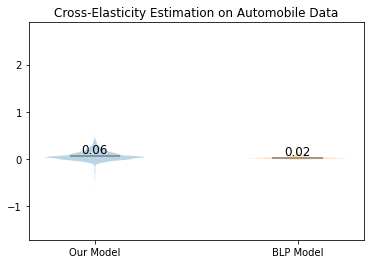

In [72]:
data = [
    large_record4_valid.loc[large_record4_valid.type == 'cross', 'deep_elasticity'].to_numpy(),
    blp_elas_df_cross['blp_elasticity'].to_numpy()
]
fig, ax = plt.subplots()

# Create the violin plot
vp = ax.violinplot(data, showextrema=False, showmeans=True)

# Set colors for each violin plot
colors = ['#1f77b4', '#FF8C00']
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])

# Change the color of the mean line
vp['cmeans'].set_color('grey')

# Set the labels for the x-axis
ax.set_xticks([1, 2])
ax.set_xticklabels(['Our Model', 'BLP Model'])

# Calculate mean values
mean_values = [np.mean(dataset) for dataset in data]

# Add the mean values as text labels on the violin plot
for i, mean in enumerate(mean_values):
    ax.text(i+1, mean, f'{mean:.2f}', ha='center', va='bottom', color='black', fontsize=12)

# Show the plot
plt.title("Cross-Elasticity Estimation on Automobile Data")
plt.savefig('cross_comparison_blp.png', dpi=300)

plt.show()


### Appenidx M - Figure A3 (b) BLP style IVs + Table A10 Row 1

In [25]:
new_iv = pd.read_csv("BLP_new_IV.csv")
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)

In [29]:
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
blp_ivs = blp_data[['prices', 'supply_instruments0',   'supply_instruments1', 'supply_instruments2', 'supply_instruments3',
       'supply_instruments4', 'supply_instruments5', 'supply_instruments6',
       'supply_instruments7', 'supply_instruments8', 'supply_instruments9',
       'supply_instruments10', 'supply_instruments11','hpwt', 'air', 'mpd', 'space'
                 ]]

blp_ivs[[ 'lag_ln_erate', 'ln_wage']] = new_iv[['lag_ln_erate', 'ln_wage']] #'lag_ln_erate', 'lag_ln_erate',
                
# 
y = blp_ivs[ 'prices']
X = blp_ivs[['supply_instruments0',   'supply_instruments1', 'supply_instruments2', 'supply_instruments3',
       'supply_instruments4', 'supply_instruments5', 'supply_instruments6',
       'supply_instruments7', 'supply_instruments8', 'supply_instruments9',
       'supply_instruments10', 'supply_instruments11','ln_wage', 'lag_ln_erate','hpwt', 'air', 'mpd', 'space']] #, 'lag_ln_erate'
X = sm.add_constant(X)


# Create and fit the OLS (Ordinary Least Squares) model
iv_model = sm.OLS(y, X).fit()
phat =  iv_model.fittedvalues
residuals = iv_model.resid

blp_data['res'] = residuals 

iv_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 prices   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     241.5
Date:                Mon, 24 Jul 2023   Prob (F-statistic):               0.00
Time:                        18:22:37   Log-Likelihood:                -6759.4
No. Observations:                2217   AIC:                         1.355e+04
Df Residuals:                    2199   BIC:                         1.366e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -70.2816     10.047     -6.995      0.000     -89.984     -50.580
supply_instruments0      1.1167      0.194      5.748      0.000       0.736       1.498
supply_instruments1     -0.0306      0.071     -0.434      0.664      -0.169       0.108
supply_instruments2      0.6450      0.074      8.714      0.000       0.500       0.790
supply_instruments3     -0.9308      0.121     -7.667      0.000      -1.169      -0.693
supply_instruments4     -1.6808      0.294     -5.717      0.000      -2.257      -1.104
supply_instruments5     -0.0344      0.049     -0.709      0.479      -0.130       0.061
supply_instruments6      0.0024      0.026      0.089      0.929      -0.050       0.054
supply_instruments7     -0.0621      0.023     -2.662      0.008      -0.108      -0.016
supply_instruments8      0.0379      0.027      1.382      0.167      -0.016       0.092
supply_instruments9      0.3031      0.102      2.962      0.003       0.102       0.504
supply_instruments10    -0.0194      0.005     -4.102      0.000      -0.029      -0.010
supply_instruments11    -0.5183      0.150     -3.455      0.001      -0.812      -0.224
ln_wage                 13.4490      2.071      6.494      0.000       9.388      17.511
lag_ln_erate             0.6474      0.071      9.103      0.000       0.508       0.787
hpwt                    30.9981      1.440     21.520      0.000      28.173      33.823
air                      8.1262      0.324     25.086      0.000       7.491       8.761
mpd                     -0.5183      0.150     -3.455      0.001      -0.812      -0.224
space                    5.3768      0.803      6.692      0.000       3.801       6.952
==============================================================================
Omnibus:                      911.007   Durbin-Watson:                   0.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6181.168
Skew:                           1.793   Prob(JB):                         0.00
Kurtosis:                      10.352   Cond. No.                     6.57e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.78e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [30]:
blp_data = blp_data[['market_ids', 'clustering_ids', 'car_ids', 'firm_ids', 'region',
       'shares', 'prices', 'hpwt', 'air', 'mpd', 'space','res']]

blp_data_new = blp_data.copy()
blp_data_new['market_code'] = pd.Categorical(blp_data_new['market_ids']).codes
blp_market_id = blp_data_new['market_code'].to_numpy()

## Get the J_list
Js = blp_data_new.groupby(['market_ids']).size().tolist() 

J_list = [0]
for m in range(len(Js)):
    J_list.append(J_list[m] + Js[m])

## sort by market code
blp_X = blp_data_new[['hpwt', 'air', 'mpd', 'space','res']]

blp_X['price'] = blp_data_new['prices']
blp_X.columns = range(len(blp_X.columns))
blp_X = blp_X.rename(columns={blp_X.columns[-1]: 'price'})

blp_Y = blp_data_new['shares'].to_numpy()

blp_data_deep = {'X': blp_X, 
             'Y': blp_Y ,  
             'M': len(blp_data['market_ids'].unique()), 
             "K": blp_X.shape[1]-1, 
            'J': blp_data.groupby(['market_ids']).size().max(), # max_J
            'J_list': J_list,
             'market_id':blp_market_id,
            'params' : 1} # the params does not mean anything here

In [31]:
m4_deep, l4_blp = train_deep_varying(blp_data_deep)

m4_pred = pred_deep_varying(blp_data_deep, m4_deep)

get_errors(m4_pred, blp_data_deep['Y'])

[7.612038682256597, 1.0371492193843164]

In [35]:
### step 5: evaluation on predicted elasticity
data = blp_data_deep
model = m4_deep
delta = 1

J = data['J']
K = data['K']
M = data['M']

large_record4  = pd.DataFrame()

for i in range(J): #i_list:#
    prod_id = i
    
    X = data['X'].copy()
    record = pd.DataFrame({'old_price' : X['price'].copy()})
    record['i'] = prod_id
    record['j'] = record.index 
    
    y_pred_old = pred_deep_varying(data, model)

    ## update price of id in all markets
    record['market_id'] = data['market_id']
    record['type'] = 'cross'
    record['price_i'] = 0
    
    for m in range(M):
        if prod_id < J_list[m+1] - J_list[m]:
            new_id = prod_id + J_list[m]
            price_i = X['price'].iloc[new_id]
            record['price_i'].iloc[J_list[m]:J_list[m+1],] = price_i 
            X['price'].iloc[new_id] =  delta + price_i
            record['type'].iloc[new_id] = "self"
            #print(prod_id, m, new_id, price_i)
    record['new_price'] = X['price'].copy()
    
    ## predict based on new price
    datax = {'X': X, 'Y': data['Y'], 'J': J, "K": K, "M": M, 'J_list': data['J_list'],"params": data['params'], 'market_id': data['market_id']}
    y_new = pred_deep_varying(datax, model)
    
    record['deep_old_share'] = y_pred_old
    record['deep_new_share'] = y_new

    record['deep_elasticity'] = (record['deep_new_share'] - record['deep_old_share']) / (delta / record['price_i'] ) #* record['deep_old_share'] because we use the log
    
    large_record4 = pd.concat([large_record4, record]).reset_index(drop=True)

In [38]:
large_record4_valid = large_record4.loc[large_record4.price_i != 0]
large_record4_valid.to_csv('raw_iv_rslt.csv')

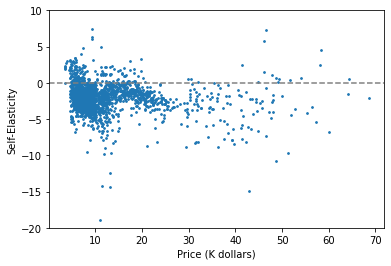

In [97]:
plt.scatter(large_record4_valid.loc[large_record4.type == 'self']['price_i'],large_record4_valid.loc[large_record4.type == 'self']['deep_elasticity'], s=3)
plt.xlabel('Price (K dollars)')
plt.ylabel('Self-Elasticity')
plt.ylim([-20,10])
#plt.title('')
plt.axhline(y=0, color='gray', linestyle='--')

plt.savefig('elas_IV_raw.png', dpi=300)

plt.show()

### Appendix M - Figure A3 (c) differentiation IV

In [60]:
product_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
product_data.head()

,market_ids,clustering_ids,car_ids,firm_ids,region,shares,prices,hpwt,air,mpd,...,supply_instruments2,supply_instruments3,supply_instruments4,supply_instruments5,supply_instruments6,supply_instruments7,supply_instruments8,supply_instruments9,supply_instruments10,supply_instruments11
0,1971,AMGREM71,129,15,US,0.0011,4.9358,0.5290,0,1.8881,...,0.0,1.7059,1.5957,87.0,-61.96,0.0,46.0604,29.787,0.0,1.8881
1,1971,AMHORN71,130,15,US,0.0007,5.5160,0.4943,0,1.9360,...,0.0,1.6809,1.4903,87.0,-61.96,0.0,46.0604,29.787,0.0,1.9360
2,1971,AMJAVL71,132,15,US,0.0003,7.1086,0.4676,0,1.7168,...,0.0,1.8011,1.3577,87.0,-61.96,0.0,46.0604,29.787,0.0,1.7168
3,1971,AMMATA71,134,15,US,0.0005,6.8395,0.4265,0,1.6879,...,0.0,1.8181,1.2613,87.0,-61.96,0.0,46.0604,29.787,0.0,1.6879
4,1971,AMAMBS71,136,15,US,0.0004,8.9284,0.4525,0,1.5043,...,0.0,1.9332,1.2374,87.0,-61.96,0.0,46.0604,29.787,0.0,1.5043


In [61]:
formulation = pyblp.Formulation('0 + hpwt + air + mpd')
local_instruments = pyblp.build_differentiation_instruments(
    formulation,
    product_data
)
local_instruments.shape

(2217, 6)

In [62]:
quadratic_instruments = pyblp.build_differentiation_instruments(
    formulation,
    product_data,
    version='quadratic'
)
quadratic_instruments

array([[2.13209553e-02, 0.00000000e+00, 2.19106877e-01, 2.01141611e+00,
        0.00000000e+00, 1.20760695e+01],
       [8.26057314e-03, 0.00000000e+00, 2.98263399e-01, 2.01426362e+00,
        0.00000000e+00, 1.19827532e+01],
       [6.39716379e-03, 0.00000000e+00, 1.23402518e-01, 2.15910350e+00,
        0.00000000e+00, 1.56777563e+01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.23933330e+00,
        6.00000000e+01, 1.31151070e+02],
       [1.46692565e-02, 0.00000000e+00, 6.31748891e-02, 1.86375553e+01,
        7.10000000e+01, 6.18482164e+01],
       [1.46692565e-02, 0.00000000e+00, 6.31748891e-02, 8.96088260e+00,
        7.10000000e+01, 8.81921451e+01]])

In [63]:
for i in range(8):
    del product_data[f'demand_instruments{i}']

for i, column in enumerate(local_instruments.T):
    product_data[f'demand_instruments{i}'] = column
    
for i, column in enumerate(quadratic_instruments.T):
    product_data[f'demand_instruments{i+6}'] = column

In [64]:
product_data.columns

Index(['market_ids', 'clustering_ids', 'car_ids', 'firm_ids', 'region',
       'shares', 'prices', 'hpwt', 'air', 'mpd', 'mpg', 'space', 'trend',
       'supply_instruments0', 'supply_instruments1', 'supply_instruments2',
       'supply_instruments3', 'supply_instruments4', 'supply_instruments5',
       'supply_instruments6', 'supply_instruments7', 'supply_instruments8',
       'supply_instruments9', 'supply_instruments10', 'supply_instruments11',
       'demand_instruments0', 'demand_instruments1', 'demand_instruments2',
       'demand_instruments3', 'demand_instruments4', 'demand_instruments5',
       'demand_instruments6', 'demand_instruments7', 'demand_instruments8',
       'demand_instruments9', 'demand_instruments10', 'demand_instruments11'],
      dtype='object')

In [65]:
new_iv = pd.read_csv("BLP_new_IV.csv")
blp_data = product_data.copy()
                
blp_ivs = blp_data[['prices', 'hpwt', 'air', 'mpd', 'space', 'demand_instruments0', 'demand_instruments1', 'demand_instruments2',
       'demand_instruments3', 'demand_instruments4', 'demand_instruments5','demand_instruments6', 'demand_instruments7', 'demand_instruments8',
       'demand_instruments9', 'demand_instruments10', 'demand_instruments11']]#
blp_ivs[[ 'ln_wage', 'lag_ln_erate']] = new_iv[[ 'ln_wage', 'lag_ln_erate']]


y = blp_ivs[ 'prices']
X = blp_ivs[['hpwt', 'air', 'mpd', 'space', 'demand_instruments0', 'demand_instruments1', 'demand_instruments2',
       'demand_instruments3', 'demand_instruments4', 'demand_instruments5','demand_instruments6', 'demand_instruments7', 'demand_instruments8',
       'demand_instruments9', 'demand_instruments10', 'demand_instruments11', 'ln_wage', 'lag_ln_erate']]

X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
iv_model = sm.OLS(y, X).fit()
phat =  iv_model.fittedvalues
residuals = iv_model.resid

blp_data['res'] = residuals 

iv_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 prices   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     276.4
Date:                Mon, 24 Jul 2023   Prob (F-statistic):               0.00
Time:                        18:48:42   Log-Likelihood:                -6615.9
No. Observations:                2217   AIC:                         1.327e+04
Df Residuals:                    2198   BIC:                         1.338e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -17.0305      4.498     -3.787      0.000     -25.850      -8.211
hpwt                    15.7801      1.612      9.791      0.000      12.620      18.941
air                      9.0326      0.524     17.235      0.000       8.005      10.060
mpd                     -4.1468      0.320    -12.945      0.000      -4.775      -3.519
space                    1.0633      0.745      1.427      0.154      -0.398       2.525
demand_instruments0     -0.0144      0.059     -0.244      0.808      -0.130       0.102
demand_instruments1     -0.0422      0.072     -0.583      0.560      -0.184       0.100
demand_instruments2      0.0336      0.041      0.829      0.407      -0.046       0.113
demand_instruments3     -0.0600      0.008     -7.840      0.000      -0.075      -0.045
demand_instruments4      0.1397      0.018      7.884      0.000       0.105       0.174
demand_instruments5     -0.0909      0.011     -8.309      0.000      -0.112      -0.069
demand_instruments6     -2.1440      0.787     -2.723      0.007      -3.688      -0.600
demand_instruments7     -0.2852      0.077     -3.715      0.000      -0.436      -0.135
demand_instruments8      0.0506      0.013      3.849      0.000       0.025       0.076
demand_instruments9      0.3047      0.069      4.431      0.000       0.170       0.440
demand_instruments10     0.1646      0.017      9.580      0.000       0.131       0.198
demand_instruments11    -0.0066      0.004     -1.499      0.134      -0.015       0.002
ln_wage                  5.7820      0.964      5.996      0.000       3.891       7.673
lag_ln_erate             0.6160      0.067      9.239      0.000       0.485       0.747
==============================================================================
Omnibus:                      887.460   Durbin-Watson:                   1.147
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6614.882
Skew:                           1.704   Prob(JB):                         0.00
Kurtosis:                      10.746   Cond. No.                     6.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [66]:
blp_data = blp_data[['market_ids', 'clustering_ids', 'car_ids', 'firm_ids', 'region',
       'shares', 'prices', 'hpwt', 'air', 'mpd', 'space','res']]

blp_data_new = blp_data.copy()
blp_data_new['market_code'] = pd.Categorical(blp_data_new['market_ids']).codes
blp_market_id = blp_data_new['market_code'].to_numpy()

## Get the J_list
Js = blp_data_new.groupby(['market_ids']).size().tolist() 

J_list = [0]
for m in range(len(Js)):
    J_list.append(J_list[m] + Js[m])

## sort by market code
blp_X = blp_data_new[['hpwt', 'air', 'mpd', 'space','res']]

blp_X['price'] = blp_data_new['prices']
blp_X.columns = range(len(blp_X.columns))
blp_X = blp_X.rename(columns={blp_X.columns[-1]: 'price'})

blp_Y = blp_data_new['shares'].to_numpy()

blp_data_deep = {'X': blp_X, 
             'Y': blp_Y ,  
             'M': len(blp_data['market_ids'].unique()), 
             "K": blp_X.shape[1]-1, 
            'J': blp_data.groupby(['market_ids']).size().max(), # max_J
            'J_list': J_list,
             'market_id':blp_market_id,
            'params' : 1} # the params does not mean anything here

m4_deep, l4_blp = train_deep_varying(blp_data_deep)
m4_pred = pred_deep_varying(blp_data_deep, m4_deep)
get_errors(m4_pred, blp_data_deep['Y'])

[7.676214868537285, 1.0326099453341429]

In [ ]:
### step 5: evaluation on predicted elasticity
data = blp_data_deep
model = m4_deep
delta = 1

J = data['J']
K = data['K']
M = data['M']

large_record4  = pd.DataFrame()

for i in range(J):
    prod_id = i
    
    X = data['X'].copy()
    record = pd.DataFrame({'old_price' : X['price'].copy()})
    record['i'] = prod_id
    record['j'] = record.index 
    
    y_pred_old = pred_deep_varying(data, model)

    ## update price of id in all markets
    record['market_id'] = data['market_id']
    record['type'] = 'cross'
    record['price_i'] = 0
    
    for m in range(M):
        if prod_id < J_list[m+1] - J_list[m]:
            new_id = prod_id + J_list[m]
            price_i = X['price'].iloc[new_id]
            record['price_i'].iloc[J_list[m]:J_list[m+1],] = price_i 
            X['price'].iloc[new_id] =  delta + price_i
            record['type'].iloc[new_id] = "self"
            #print(prod_id, m, new_id, price_i)
    record['new_price'] = X['price'].copy()
    
    ## predict based on new price
    datax = {'X': X, 'Y': data['Y'], 'J': J, "K": K, "M": M, 'J_list': data['J_list'],"params": data['params'], 'market_id': data['market_id']}
    y_new = pred_deep_varying(datax, model)
    
    record['deep_old_share'] = y_pred_old
    record['deep_new_share'] = y_new

    record['deep_elasticity'] = (record['deep_new_share'] - record['deep_old_share']) / (delta / record['price_i'] ) #* record['deep_old_share'] because we use the log
    
    large_record4 = pd.concat([large_record4, record]).reset_index(drop=True)

our_rslt2 = pd.DataFrame(large_record4.loc[(large_record4.market_id == 19) &
                        (large_record4['i'].isin(i_list)) & 
                         (large_record4['j'].isin(j_list))]['deep_elasticity'].to_numpy().reshape((13,13)))

car_names = blp_data.iloc[j_list,]['clustering_ids'].to_list()
our_rslt2.index = car_names
our_rslt2.columns = car_names

In [68]:
large_record4_valid = large_record4.loc[large_record4.price_i != 0]
large_record4_valid.to_csv('diff_iv_rslt.csv')

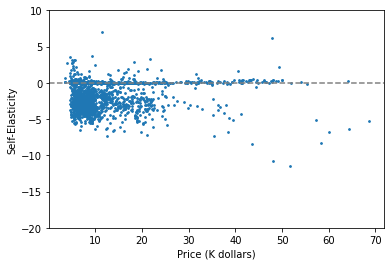

In [78]:
large_record4_valid = pd.read_csv("diff_iv_rslt.csv")
plt.scatter(large_record4_valid.loc[large_record4.type == 'self']['price_i'],large_record4_valid.loc[large_record4.type == 'self']['deep_elasticity'], s=3)
plt.xlabel('Price (K dollars)')
plt.ylabel('Self-Elasticity')
plt.ylim([-20,10])
#plt.title('')
plt.axhline(y=0, color='gray', linestyle='--')

plt.savefig('elas_IV_diff.png', dpi=300)

plt.show()

### Appendix M - Figure A4

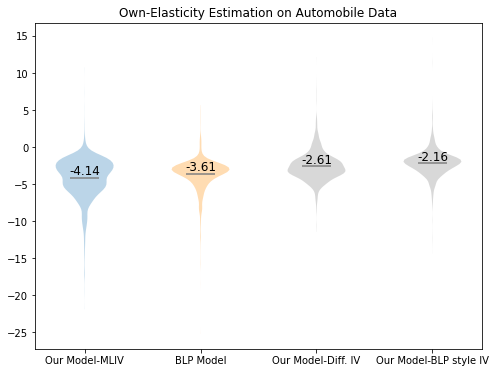

In [86]:
raw_rslt = pd.read_csv('raw_iv_rslt.csv')
ml_rslt = pd.read_csv('IV_rslt.csv')
blp_rslt = pd.read_csv('blp_elas_df.csv')
diff_rslt = pd.read_csv('diff_iv_rslt.csv')

data = [ml_rslt.loc[ml_rslt.type == 'self','deep_elasticity'].to_numpy(), blp_rslt.loc[raw_rslt.type == 'self','blp_elasticity'].to_numpy(), 
        diff_rslt.loc[diff_rslt.type == 'self','deep_elasticity'].to_numpy(), 
        raw_rslt.loc[raw_rslt.type == 'self','deep_elasticity'].to_numpy()]
fig, ax = plt.subplots(figsize=(8, 6)) 

# Create the violinplot
violins = ax.violinplot(data, showextrema = False, showmeans = True)

# Set colors for each violin plot
colors = ['#1f77b4', '#FF8C00', 'grey','grey']
for i, body in enumerate(violins['bodies']):
    body.set_facecolor(colors[i])

violins['cmeans'].set_color('grey')

# Set the labels for the x-axis
ax.set_xticks([1, 2,3, 4])
ax.set_xticklabels(['Our Model-MLIV', 'BLP Model', 'Our Model-Diff. IV', 'Our Model-BLP style IV'])

plt.title("Own-Elasticity Estimation on Automobile Data")

# Calculate mean values
mean_values = [np.mean(dataset) for dataset in data]

# Add the mean values as text labels on the violin plot
for i, mean in enumerate(mean_values):
    ax.text(i+1, mean, f'{mean:.2f}', ha='center', va='bottom', color='black', fontsize=12)

# Show the plot
plt.savefig('self_comparison_blp.png', dpi=300)

plt.show()

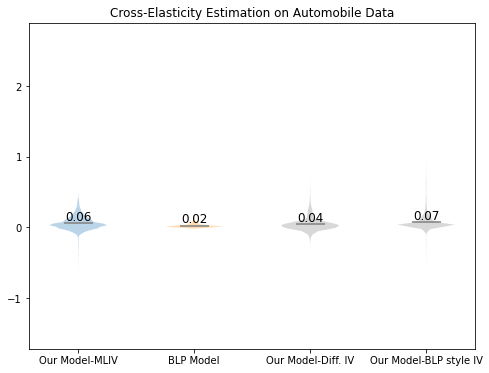

In [87]:
raw_rslt = pd.read_csv('raw_iv_rslt.csv')
ml_rslt = pd.read_csv('IV_rslt.csv')
blp_rslt = pd.read_csv('blp_elas_df.csv')
diff_rslt = pd.read_csv('diff_iv_rslt.csv')

data = [ml_rslt.loc[ml_rslt.type == 'cross','deep_elasticity'].to_numpy(), blp_rslt.loc[raw_rslt.type == 'cross','blp_elasticity'].to_numpy(), 
        diff_rslt.loc[diff_rslt.type == 'cross','deep_elasticity'].to_numpy(), 
        raw_rslt.loc[raw_rslt.type == 'cross','deep_elasticity'].to_numpy()]
fig, ax = plt.subplots(figsize=(8, 6)) 
# Create the violinplot
violins = ax.violinplot(data, showextrema = False, showmeans = True)

# Set colors for each violin plot
colors = ['#1f77b4', '#FF8C00', 'grey','grey']
for i, body in enumerate(violins['bodies']):
    body.set_facecolor(colors[i])

violins['cmeans'].set_color('grey')

# Set the labels for the x-axis
ax.set_xticks([1, 2,3, 4])
ax.set_xticklabels(['Our Model-MLIV', 'BLP Model', 'Our Model-Diff. IV', 'Our Model-BLP style IV'])

plt.title("Cross-Elasticity Estimation on Automobile Data")

# Calculate mean values
mean_values = [np.mean(dataset) for dataset in data]

# Add the mean values as text labels on the violin plot
for i, mean in enumerate(mean_values):
    ax.text(i+1, mean, f'{mean:.2f}', ha='center', va='bottom', color='black', fontsize=12)

# Show the plot
plt.savefig('cross_comparison_blp.png', dpi=300)

plt.show()

### Appendix M - Table A10 Row 2 (F-stats)

In [11]:
blp_data = pd.read_csv(pyblp.data.BLP_PRODUCTS_LOCATION)
new_iv = pd.read_csv("BLP_new_IV.csv")

blp_ivs = blp_data[['prices', 'supply_instruments0',   'supply_instruments1', 'supply_instruments2', 'supply_instruments3',
       'supply_instruments4', 'supply_instruments5', 'supply_instruments6',
       'supply_instruments7', 'supply_instruments8', 'supply_instruments9',
       'supply_instruments10', 'supply_instruments11',
                 ]]#
              


blp_ivs[[ 'lag_ln_erate', 'ln_wage']] = new_iv[['lag_ln_erate', 'ln_wage']] #'lag_ln_erate', 'lag_ln_erate',
        #'japan', 'japan_trend', 'euro','euro_trend',        
# use the mliv
regr = LassoCV(cv = 3, random_state = 234) # XGBRegressor(cv = 3) #LassoCV(cv = 2)# or 
blp_ivs['liv'] = cross_val_predict(regr , blp_ivs[[col for col in blp_ivs.columns if col != 'prices']], blp_ivs['prices'], cv = 3)

# 
y = blp_ivs[ 'prices']
X = blp_ivs[['liv']] #
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
iv_model = sm.OLS(y, X).fit()
phat =  iv_model.fittedvalues
residuals = iv_model.resid

blp_data['res'] = residuals 

iv_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 prices   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     280.9
Date:                Mon, 24 Jul 2023   Prob (F-statistic):           1.90e-59
Time:                        17:24:22   Log-Likelihood:                -7794.7
No. Observations:                2217   AIC:                         1.559e+04
Df Residuals:                    2215   BIC:                         1.560e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3290      0.421     12.658      0.000       4.503       6.155
liv            0.5834      0.035     16.759      0.000       0.515       0.652
==============================================================================
Omnibus:                     1183.566   Durbin-Watson:                   0.766
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8477.346
Skew:                           2.466   Prob(JB):                         0.00
Kurtosis:                      11.212   Cond. No.                         29.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""